**Atresia** refers to the process by which ovarian follicles degenerate and are reabsorbed before reaching maturity. This is a natural part of the ovarian cycle in females and affects the majority of follicles within the ovaries.

### Detailed Explanation:

1. **Ovarian Follicles**:
   - **Definition**: Ovarian follicles are small fluid-filled sacs within the ovaries that contain immature eggs (oocytes). Each follicle nurtures an oocyte and supports its development.
   - **Follicular Development**: Follicles go through several stages of development: primordial, primary, secondary, and tertiary (or antral). Only a small number of follicles reach the later stages of development.

2. **Atresia**:
   - **Definition**: Atresia is the process of degeneration and reabsorption of ovarian follicles that do not complete their development. This process can occur at any stage of follicular development.
   - **Mechanism**: Atresia involves apoptosis (programmed cell death) of the follicular cells and the oocyte. The breakdown products are then phagocytosed by surrounding cells and reabsorbed into the ovarian tissue.

3. **Significance of Atresia**:
   - **Follicular Reserve**: Females are born with a finite number of primordial follicles, which constitute the ovarian reserve. Throughout a woman’s reproductive life, many of these follicles undergo atresia, with only a fraction reaching ovulation.
   - **Regulation**: Atresia is regulated by hormonal signals and intra-ovarian factors. Key hormones involved include follicle-stimulating hormone (FSH) and luteinizing hormone (LH). Lower levels of FSH, for instance, can lead to increased atresia of developing follicles.
   - **Selection**: The process of atresia allows for the selection of the healthiest follicles for ovulation. Typically, only one follicle (in humans) becomes the dominant follicle that is capable of ovulating, while the others undergo atresia.

4. **Clinical Relevance**:
   - **Fertility**: The rate of follicular atresia has implications for fertility. A higher rate of atresia can reduce the number of available eggs for ovulation, potentially impacting fertility.
   - **Aging**: As women age, the number of follicles that can mature and ovulate decreases, partly due to the cumulative effect of atresia. This contributes to the decline in fertility with age.
   - **Polycystic Ovary Syndrome (PCOS)**: In conditions like PCOS, atresia may be altered, leading to the presence of multiple immature follicles and hormonal imbalances that affect ovulation and fertility.

### Summary:

**Atresia** in the context of ovarian cells refers to the natural process of follicular degeneration and reabsorption, which prevents many ovarian follicles from reaching maturity and ovulation. This process is a key component of ovarian physiology, regulating the selection of follicles for ovulation and maintaining the ovarian reserve. Understanding atresia is important in reproductive biology and has significant implications for fertility and ovarian health.

In [1]:
from datetime import datetime
str(datetime.now())

'2024-07-23 10:43:28.946677'

In [2]:
import matplotlib.pyplot as plt
import scanpy as sc
import numpy as np
import pandas as pd

In [3]:
# Load the H5AD file
adata_original = sc.read_h5ad('ovary_Puck_230517_39.h5ad')

In [4]:
adata = adata_original

# Basic exploratory analysis of the data

Spatial coordinates found in adata.obsm['spatial']:
[[3832.1 2726.6]
 [3475.2 2551.7]
 [2123.2 2040.9]
 ...
 [2917.8 2360.9]
 [2980.1 2923.6]
 [1810.1 1914.8]]


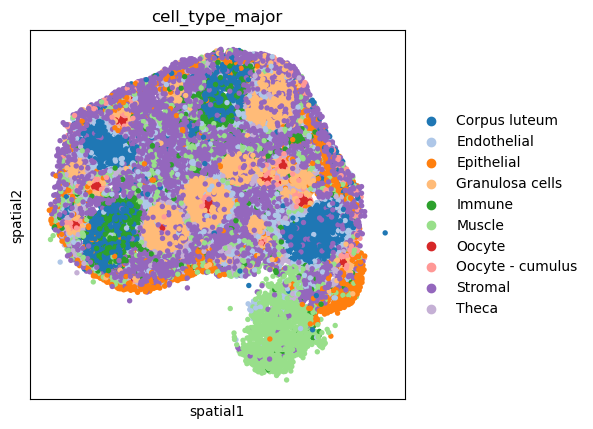

In [5]:
# Check the content of 'spatial' to ensure it exists and is in the correct format
if 'spatial' in adata.obsm.keys():
    print("Spatial coordinates found in adata.obsm['spatial']:")
    print(adata.obsm['spatial'])
else:
    print("No spatial coordinates found in adata.obsm['spatial']")

# Provide spot_size directly if .uns['spatial'][library_id] does not exist
sc.pl.spatial(
    adata,
    color='cell_type_major',  # You can specify a column in adata.obs to color by if desired
    basis='spatial',  # Specify the key in obsm to use for spatial coordinates
    spot_size=50,  # Adjust this value as necessary for your data
    show=True,
)

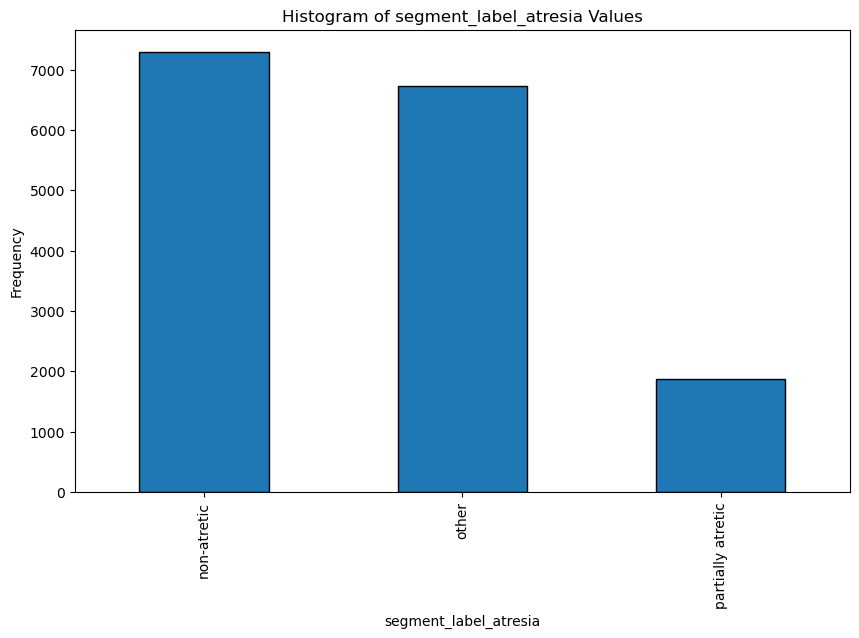

In [6]:
column = "segment_label_atresia"
values = adata.obs[column]
plt.figure(figsize=(10, 6))
values.value_counts().plot(kind='bar', edgecolor='black')
plt.title(f'Histogram of {column} Values')
plt.xlabel(column)
plt.ylabel('Frequency')
plt.show()

An important notice here is to not use the raw data set.  Otherwise, you would have been looking at genes that have been excluded by earlier pre-processing. 

# Differential Expression Analysis

  partially atretic_n  partially atretic_l  partially atretic_p other_n  \
0            Serpine2           155.165939         1.828295e-40   Tagln   
1               Tdrd5            33.936779         1.293942e-24    Tpm2   
2               Foxo1            30.784809         1.407478e-17   Acta2   
3                Rgs2            52.229477         1.981284e-16   Myh11   
4             Adamts2            24.792843         4.068850e-16    Mylk   

      other_l        other_p  
0  204.425369  6.033824e-154  
1  187.819031  2.604215e-149  
2  128.172470  2.754869e-134  
3  106.694695  3.692757e-113  
4   90.424385  7.884603e-106  


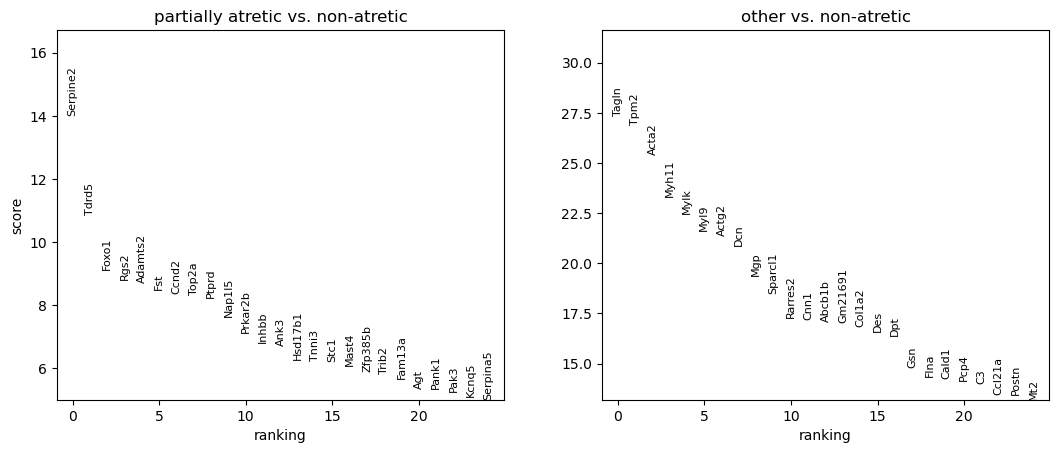

In [7]:
# Perform DEG analysis
sc.tl.rank_genes_groups(adata, 'segment_label_atresia', groups=['partially atretic', 'other'], reference='non-atretic', method='t-test',  use_raw=False)

# Extract and display the results
result = adata.uns['rank_genes_groups']
groups = result['names'].dtype.names
degs = pd.DataFrame(
    {group + '_' + key[:1]: result[key][group]
     for group in groups for key in ['names', 'logfoldchanges', 'pvals', 'pvals_adj']}
)

print(degs.head())

# Visualize the top differentially expressed genes
sc.pl.rank_genes_groups(adata, n_genes=25, sharey=False)

  non-atretic_n  non-atretic_l  non-atretic_p other_n     other_l  \
0        S100a6     103.243958  1.190392e-172     Mgp  143.315338   
1         Sfrp4      72.507042  8.594534e-123   Tagln  213.376755   
2       Smarca1      96.974030  3.731205e-117    Tpm2  188.003586   
3         Ltbp1      41.085728   2.463237e-94  Col1a2  166.697845   
4         Ptgfr      31.731037   2.190457e-77   Actg2   70.821556   

         other_p  
0  1.005245e-163  
1  1.193169e-156  
2  7.568816e-132  
3  3.357267e-107  
4   1.547328e-86  


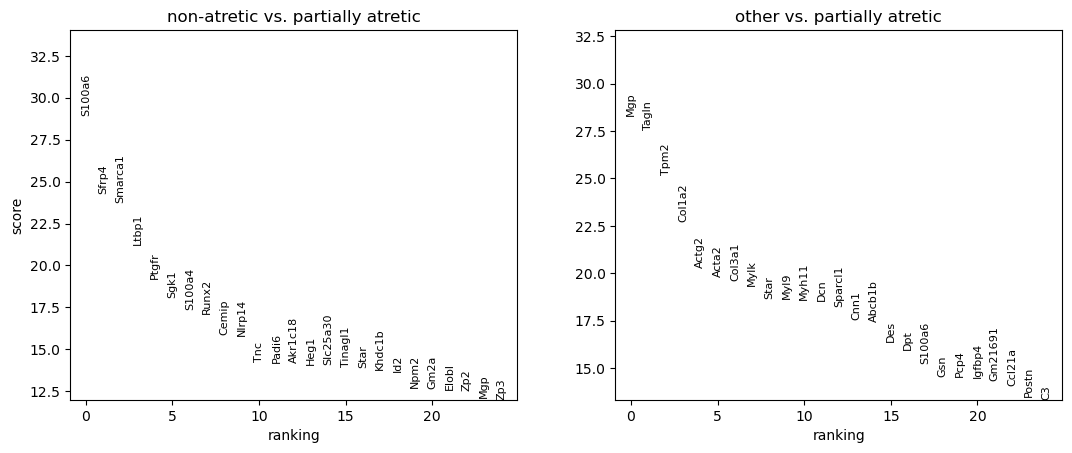

In [8]:
# Perform DEG analysis
sc.tl.rank_genes_groups(adata, 'segment_label_atresia', groups=['non-atretic', 'other'], reference='partially atretic', method='t-test',use_raw=False)

# Extract and display the results
result = adata.uns['rank_genes_groups']
groups = result['names'].dtype.names
degs = pd.DataFrame(
    {group + '_' + key[:1]: result[key][group]
     for group in groups for key in ['names', 'logfoldchanges', 'pvals', 'pvals_adj']}
)

print(degs.head())

# Visualize the top differentially expressed genes
sc.pl.rank_genes_groups(adata, n_genes=25, sharey=False)

  non-atretic_n  non-atretic_l  non-atretic_p partially atretic_n  \
0      Serpine2     137.606842  9.189538e-212            Serpine2   
1         Nr5a2      62.948723  7.404210e-167               Nr5a2   
2         Inhba      55.781212  4.822483e-126             Prkar2b   
3         Sfrp4      63.768406  6.359249e-100              Nap1l5   
4       Prkar2b      53.611923   5.582373e-82                 Fst   

   partially atretic_l  partially atretic_p  
0           292.772766        4.790028e-139  
1            69.232254         2.177425e-67  
2            91.552834         5.905208e-66  
3            60.155727         4.109530e-62  
4            46.590939         8.013014e-60  


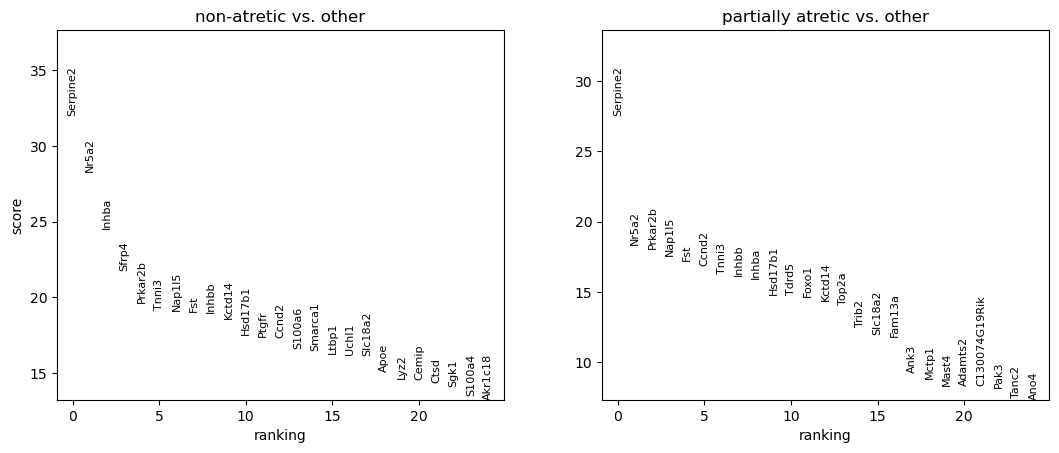

In [9]:
# Perform DEG analysis
sc.tl.rank_genes_groups(adata, 'segment_label_atresia', groups=['non-atretic', 'partially atretic'], reference='other', method='t-test', use_raw=False)

# Extract and display the results
result = adata.uns['rank_genes_groups']
groups = result['names'].dtype.names
degs = pd.DataFrame(
    {group + '_' + key[:1]: result[key][group]
     for group in groups for key in ['names', 'logfoldchanges', 'pvals', 'pvals_adj']}
)

print(degs.head())

# Visualize the top differentially expressed genes
sc.pl.rank_genes_groups(adata, n_genes=25, sharey=False)

# Isolate Gene Expression Values and Writing into a data frame

In [10]:
def isolate_gene_values (gene_name):
    gene_values = pd.DataFrame(adata[:, gene_name].X.toarray(), columns = [gene_name], index = adata.obs_names)
    return gene_values

In [11]:
coordinates = pd.DataFrame(adata.obsm["spatial"], columns = ['x','y'], index = adata.obs_names)

In [12]:
df = pd.concat([coordinates, isolate_gene_values("Serpine2"),isolate_gene_values("Tagln")], axis =1)

In [13]:
df=df.sample(frac=1)
df=df.head(8000)

In [14]:
print(len(isolate_gene_values("Tagln")["Tagln"].unique()))
print(len(isolate_gene_values("Serpine2")["Serpine2"].unique()))

1910
2989


SerpinE2 is required in the extracellular milieu of breast tumors where it acts in multiple ways to regulate tumor matrix deposition, thereby controlling tumor cell dissemination.

The Tagln gene encodes a shape change and transformation sensitive actin-binding protein which belongs to the calponin family. It is ubiquitously expressed in vascular and visceral smooth muscle, and is an early marker of smooth muscle differentiation. The encoded protein is thought to be involved in calcium-independent smooth muscle contraction. It acts as a tumor suppressor, and the loss of its expression is an early event in cell transformation and the development of some tumors, coinciding with cellular plasticity. 

# From Python DataFrame to R List Vector

In [15]:
import rpy2.robjects as robjects
from rpy2.robjects.packages import importr
from rpy2.robjects.vectors import FloatVector, ListVector
from rpy2.robjects import pandas2ri
from rpy2.robjects.numpy2ri import numpy2rpy
from rpy2.robjects import r
# Import necessary R packages
geoR = importr('geoR')

pandas2ri.activate()
robjects.numpy2ri.activate()

In [16]:
# Converting from pandas DataFrame to ListVector
def df_to_list_vector (df, gene_name):
    
    # Extract the coordinates as a numpy array
    coords = df[['x', 'y']].to_numpy()
    # Turn it into a float array
    r_coords = numpy2rpy(coords)
    
    # Extract the gene expression values as a float vector
    r_gene_expression = FloatVector(df[gene_name])
    
    # Create the R list vector
    r_list = ListVector({
        'coords': r_coords,
        'data': r_gene_expression,
        'gene name': gene_name
        
    })
    
    # Print the R list vector
    return(r_list)

s200 = df_to_list_vector(df,gene_name = "Tagln")
print(s200)

$coords
          [,1]   [,2]
   [1,] 1979.8 2593.0
   [2,] 2500.8 2798.7
   [3,] 3827.9 3059.2
   [4,] 3591.3 3895.4
   [5,] 3911.6 2202.3
   [6,] 2246.7 3331.1
   [7,] 2312.5 3066.9
   [8,] 3268.2 2800.2
   [9,] 3378.0 3055.8
  [10,] 3488.8 3649.6
  [11,] 3584.3 1705.8
  [12,] 3242.9 1537.8
  [13,] 3002.3 1647.8
  [14,] 3535.3 1703.1
  [15,] 3253.7 1578.7
  [16,] 2490.5 3528.2
  [17,] 2211.1 2915.6
  [18,] 2014.7 2250.0
  [19,] 2719.8 1996.5
  [20,] 3466.0 2620.0
  [21,] 3226.1 2538.4
  [22,] 3788.1 4035.0
  [23,] 2739.9 2750.3
  [24,] 3862.0 2633.8
  [25,] 3028.1 1373.6
  [26,] 2825.0 2198.0
  [27,] 3634.7 1746.9
  [28,] 3766.3 2582.1
  [29,] 3704.2 1532.6
  [30,] 2505.8 1660.2
  [31,] 3250.2 3280.4
  [32,] 2776.3 3225.9
  [33,] 2809.2 2119.7
  [34,] 1825.4 2374.3
  [35,] 4154.2 2889.0
  [36,] 2103.5 1886.0
  [37,] 3716.1 1523.7
  [38,] 2040.0 3280.1
  [39,] 2886.6 2678.3
  [40,] 4190.4 2831.7
  [41,] 2433.0 2067.1
  [42,] 4172.2 3728.8
  [43,] 1829.1 2960.4
  [44,] 3663.9 1590.6
  

In [17]:
# Assign s200 to the R environment
robjects.globalenv['s200'] = s200

In [18]:
%%time 
r_code = """
ml <- likfit(s200, cov.model = 'matern', kappa = 1.5, ini = c(0.9, 0.2),nug = 0.2)
ml
"""
result = r(r_code)
print(result)

---------------------------------------------------------------
likfit: likelihood maximisation using the function optim.
likfit: Use control() to pass additional
         arguments for the maximisation function.
        For further details see documentation for optim.
likfit: It is highly advisable to run this function several
        times with different initial values for the parameters.
likfit: WARNING: This step can be time demanding!
---------------------------------------------------------------
likfit: end of numerical maximisation.

likfit: estimated model parameters:
      beta      tausq    sigmasq        phi 
"   84.03" "14035.81" "63161.16" "    0.20" 
Practical Range with cor=0.05 for asymptotic range: 0.9487599

likfit: maximised log-likelihood = -56368

CPU times: user 9min 9s, sys: 24.3 s, total: 9min 34s
Wall time: 9min 40s


In [19]:
%%time
r_code = """
ml <- likfit(s200, cov.model = 'exponential', kappa = 1.5, ini = c(0.9, 0.2), nug = 0.2)
ml
"""
result = r(r_code)
print(result)

kappa not used for the exponential correlation function
---------------------------------------------------------------
likfit: likelihood maximisation using the function optim.
likfit: Use control() to pass additional
         arguments for the maximisation function.
        For further details see documentation for optim.
likfit: It is highly advisable to run this function several
        times with different initial values for the parameters.
likfit: WARNING: This step can be time demanding!
---------------------------------------------------------------
likfit: end of numerical maximisation.

likfit: estimated model parameters:
      beta      tausq    sigmasq        phi 
"   84.03" "14035.81" "63161.16" "    0.20" 
Practical Range with cor=0.05 for asymptotic range: 0.5991212

likfit: maximised log-likelihood = -56368

CPU times: user 7min 42s, sys: 17.5 s, total: 7min 59s
Wall time: 8min 5s


In [20]:
s200 = df_to_list_vector(df,gene_name = "Serpine2")

In [21]:
print(s200)

$coords
          [,1]   [,2]
   [1,] 1979.8 2593.0
   [2,] 2500.8 2798.7
   [3,] 3827.9 3059.2
   [4,] 3591.3 3895.4
   [5,] 3911.6 2202.3
   [6,] 2246.7 3331.1
   [7,] 2312.5 3066.9
   [8,] 3268.2 2800.2
   [9,] 3378.0 3055.8
  [10,] 3488.8 3649.6
  [11,] 3584.3 1705.8
  [12,] 3242.9 1537.8
  [13,] 3002.3 1647.8
  [14,] 3535.3 1703.1
  [15,] 3253.7 1578.7
  [16,] 2490.5 3528.2
  [17,] 2211.1 2915.6
  [18,] 2014.7 2250.0
  [19,] 2719.8 1996.5
  [20,] 3466.0 2620.0
  [21,] 3226.1 2538.4
  [22,] 3788.1 4035.0
  [23,] 2739.9 2750.3
  [24,] 3862.0 2633.8
  [25,] 3028.1 1373.6
  [26,] 2825.0 2198.0
  [27,] 3634.7 1746.9
  [28,] 3766.3 2582.1
  [29,] 3704.2 1532.6
  [30,] 2505.8 1660.2
  [31,] 3250.2 3280.4
  [32,] 2776.3 3225.9
  [33,] 2809.2 2119.7
  [34,] 1825.4 2374.3
  [35,] 4154.2 2889.0
  [36,] 2103.5 1886.0
  [37,] 3716.1 1523.7
  [38,] 2040.0 3280.1
  [39,] 2886.6 2678.3
  [40,] 4190.4 2831.7
  [41,] 2433.0 2067.1
  [42,] 4172.2 3728.8
  [43,] 1829.1 2960.4
  [44,] 3663.9 1590.6
  

In [22]:
# Assign s200 to the R environment
robjects.globalenv['s200'] = s200

In [23]:
%%time 
r_code = """
ml <- likfit(s200, cov.model = 'matern', kappa = 1.5, ini = c(0.9, 0.2),nug = 0.2)
ml
"""
result = r(r_code)
print(result)

---------------------------------------------------------------
likfit: likelihood maximisation using the function optim.
likfit: Use control() to pass additional
         arguments for the maximisation function.
        For further details see documentation for optim.
likfit: It is highly advisable to run this function several
        times with different initial values for the parameters.
likfit: WARNING: This step can be time demanding!
---------------------------------------------------------------
likfit: end of numerical maximisation.

likfit: estimated model parameters:
     beta     tausq   sigmasq       phi 
"  107.0" " 7917.0" "35626.3" "    0.2" 
Practical Range with cor=0.05 for asymptotic range: 0.9487599

likfit: maximised log-likelihood = -54078

CPU times: user 5min 12s, sys: 13.4 s, total: 5min 25s
Wall time: 5min 29s


In [24]:
%%time
r_code = """
ml <- likfit(s200, cov.model = 'exponential', kappa = 1.5, ini = c(0.9, 0.2), nug = 0.2)
ml
"""
result = r(r_code)
print(result)

kappa not used for the exponential correlation function
---------------------------------------------------------------
likfit: likelihood maximisation using the function optim.
likfit: Use control() to pass additional
         arguments for the maximisation function.
        For further details see documentation for optim.
likfit: It is highly advisable to run this function several
        times with different initial values for the parameters.
likfit: WARNING: This step can be time demanding!
---------------------------------------------------------------
likfit: end of numerical maximisation.

likfit: estimated model parameters:
     beta     tausq   sigmasq       phi 
"  107.0" " 7917.0" "35626.3" "    0.2" 
Practical Range with cor=0.05 for asymptotic range: 0.5991212

likfit: maximised log-likelihood = -54078

CPU times: user 4min 27s, sys: 9.25 s, total: 4min 37s
Wall time: 4min 39s


# From R ListVector to Python DataFrame

In [25]:
# Converting from ListVector to pandas DataFrame
# Example data: using 's100' dataset from geoR package
robjects.r('data(s100)')
s100=robjects.r('s100')

df1 = pd.concat([pd.DataFrame(list(s100[0][:,0]), columns = ['x']), pd.DataFrame(list(s100[0][:,1]), columns = ['y']), pd.DataFrame(list(s100[1]), columns = ['z'])], axis=1)
df1

,x,y,z
0,0.807127,0.945446,0.917189
1,0.549998,0.683265,1.148323
2,0.340806,0.458509,1.032756
3,0.137099,0.472008,0.121955
4,0.044186,0.122320,0.615299
...,...,...,...
95,0.585834,0.448930,1.284822
96,0.541334,0.134994,0.757246
97,0.406254,0.963111,0.186185
98,0.495318,0.173570,0.891085


In [26]:
robjects.r['pi'][0]

3.141592653589793

In [27]:
from datetime import datetime
str(datetime.now())

'2024-07-23 11:11:51.280345'